# Car Price Prediction

**Track:** Data Science | **Task 3 — OIBSIP**

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage (kms driven), fuel type, and transmission.

**Dataset:** Vehicle Dataset from CarDekho (Kaggle) — `car data.csv`

# 1. Imports & Setup

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# LOAD DATA
file_path = '/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv'
df = pd.read_csv(file_path)

# FEATURE ENGINEERING
CURRENT_YEAR = 2024
df['Car_Age'] = CURRENT_YEAR - df['Year']
df['Brand'] = df['Car_Name'].str.split().str[0].str.lower()
df = df.drop(['Year', 'Car_Name'], axis=1)

# CLEAN
df = df.drop_duplicates().copy()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.title()

print("✅ Everything loaded and ready!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ Everything loaded and ready!
Shape: (299, 9)
Columns: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Brand']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,Ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,Sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,Ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,Wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,Swift


# 2. Data Inspection
Checking data types, missing values, and descriptive statistics to understand the quality of our dataset.

In [2]:
print("Data Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDescriptive Statistics:")
df.describe()

Data Types:
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
Car_Age            int64
Brand             object
dtype: object

Missing Values:
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Car_Age          0
Brand            0
dtype: int64

Descriptive Statistics:


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,4.589632,7.541037,36916.752508,0.043478,10.384615
std,4.984240,8.567887,39015.170352,0.248720,2.896868
min,0.100000,0.320000,500.000000,0.000000,6.000000
25%,0.850000,1.200000,15000.000000,0.000000,8.000000
50%,3.510000,6.100000,32000.000000,0.000000,10.000000
75%,6.000000,9.840000,48883.500000,0.000000,12.000000
max,35.000000,92.600000,500000.000000,3.000000,21.000000


# 3. Exploratory Data Analysis (EDA)

## 3.1 Selling Price Distribution
Analysing how the target variable (Selling Price) is distributed. Most cars are priced under 10 Lakhs with a few expensive outliers.

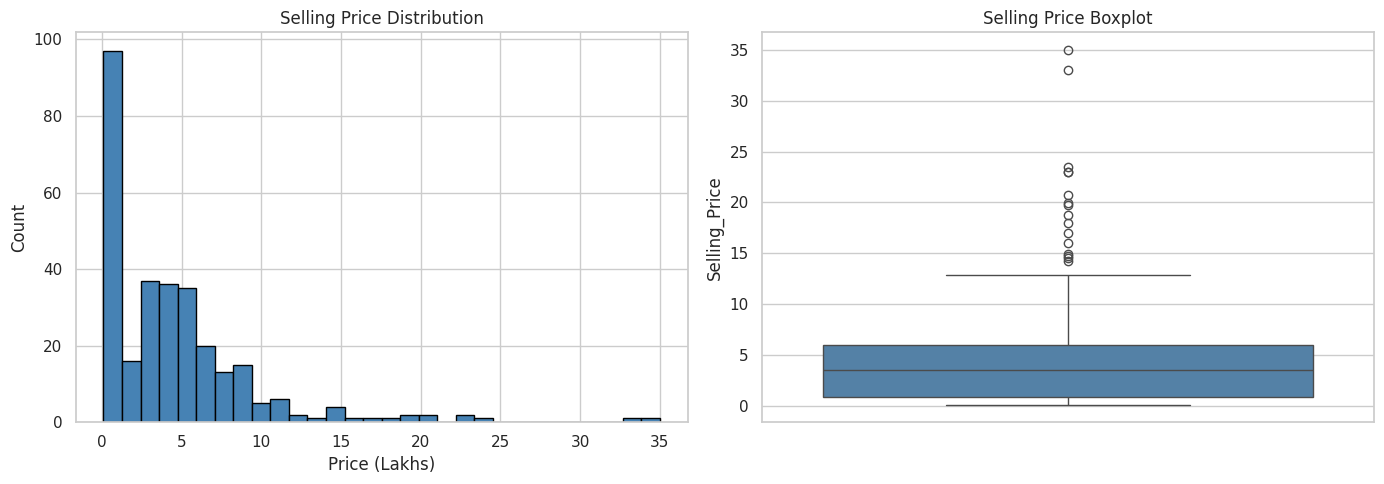

Mean:   4.59 Lakhs
Median: 3.51 Lakhs


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Selling Price Distribution')
axes[0].set_xlabel('Price (Lakhs)')
axes[0].set_ylabel('Count')

sns.boxplot(y=df['Selling_Price'], color='steelblue', ax=axes[1])
axes[1].set_title('Selling Price Boxplot')

plt.tight_layout()
plt.show()

print(f"Mean:   {df['Selling_Price'].mean():.2f} Lakhs")
print(f"Median: {df['Selling_Price'].median():.2f} Lakhs")

## 3.2 Selling Price vs Fuel Type
Comparing how different fuel types affect the resale value. Diesel cars tend to have higher resale prices than petrol and CNG cars.

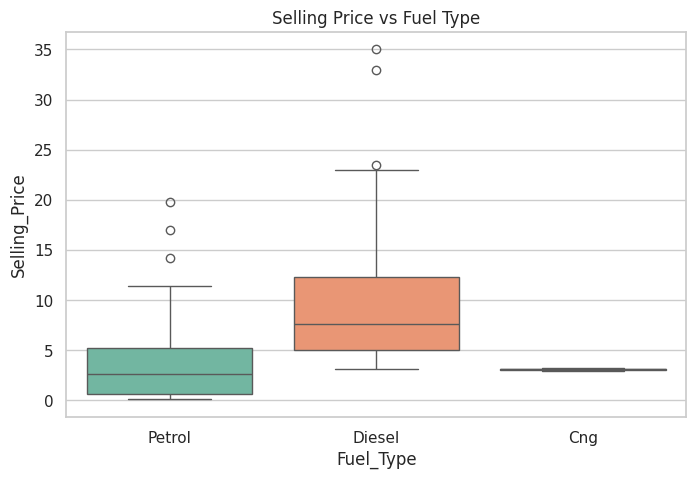

Average price by fuel type:
Fuel_Type
Cng        3.10
Diesel    10.10
Petrol     3.26
Name: Selling_Price, dtype: float64


In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, 
            hue='Fuel_Type', palette='Set2', legend=False)
plt.title('Selling Price vs Fuel Type')
plt.show()

print("Average price by fuel type:")
print(df.groupby('Fuel_Type')['Selling_Price'].mean().round(2))

## 3.3 Selling Price vs Car Age
Examining the relationship between a car's age and its selling price. Newer cars sell for significantly more than older ones.

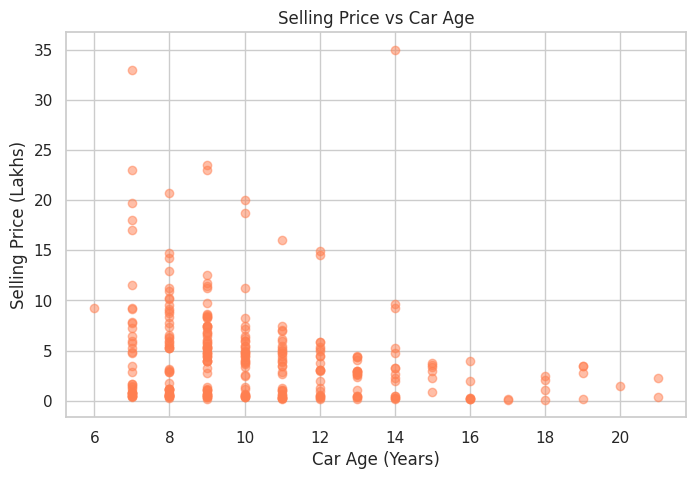

Observation: Older cars sell for less


In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Car_Age'], df['Selling_Price'], alpha=0.5, color='coral')
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

print("Observation: Older cars sell for less")

## 3.4 Selling Price vs Transmission
Comparing manual vs automatic transmission car prices. Automatic cars tend to hold their value better.

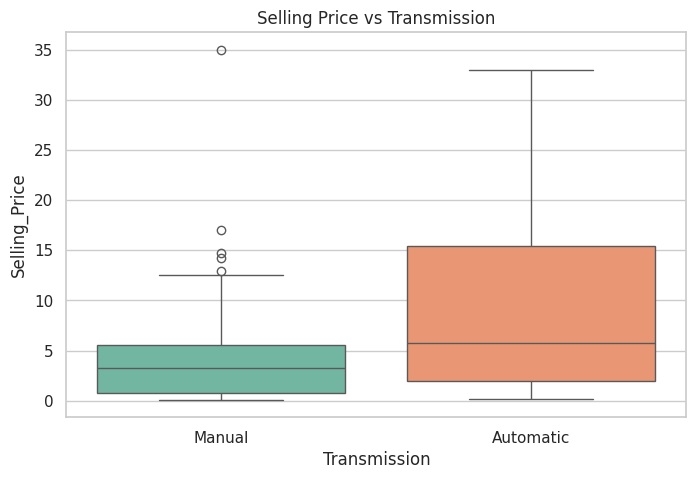

Average price by transmission:
Transmission
Automatic    9.07
Manual       3.92
Name: Selling_Price, dtype: float64


In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Transmission', y='Selling_Price', data=df,
            hue='Transmission', palette='Set2', legend=False)
plt.title('Selling Price vs Transmission')
plt.show()

print("Average price by transmission:")
print(df.groupby('Transmission')['Selling_Price'].mean().round(2))

## 3.5 Selling Price vs Kilometers Driven
Checking if higher mileage reduces the car's resale value. Cars with lower km driven generally sell for more.

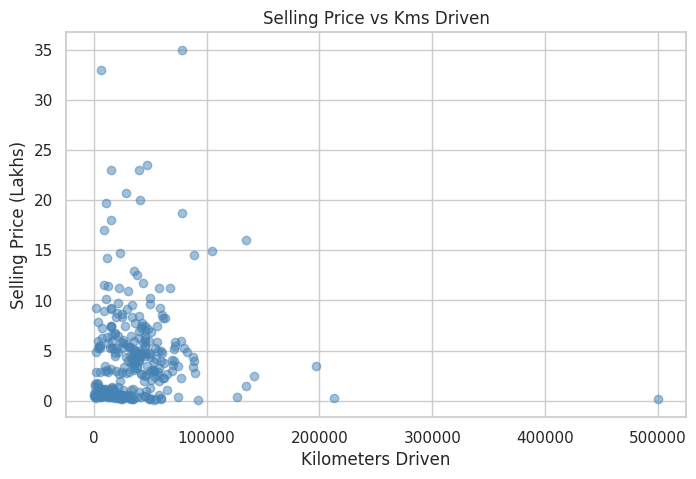

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Kms_Driven'], df['Selling_Price'], alpha=0.5, color='steelblue')
plt.title('Selling Price vs Kms Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

## 3.6 Top 10 Car Brands
Which car brands appear most frequently in the dataset? Maruti dominates the used car market.

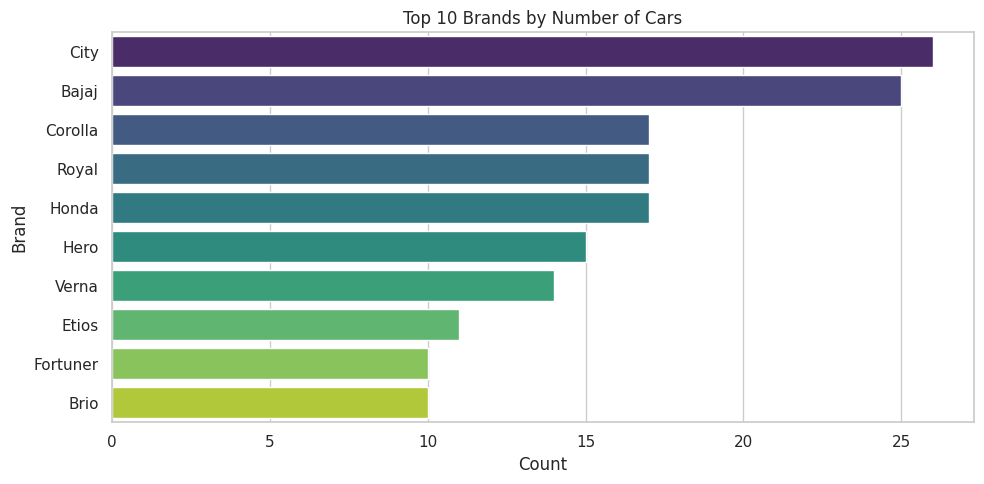

In [8]:
plt.figure(figsize=(10, 5))
brand_counts = df['Brand'].value_counts().head(10)
sns.barplot(x=brand_counts.values, y=brand_counts.index, 
            hue=brand_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Brands by Number of Cars')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

## 3.7 Correlation Heatmap
Examining the linear relationships between all numerical features. Present_Price has the highest positive correlation with Selling_Price.

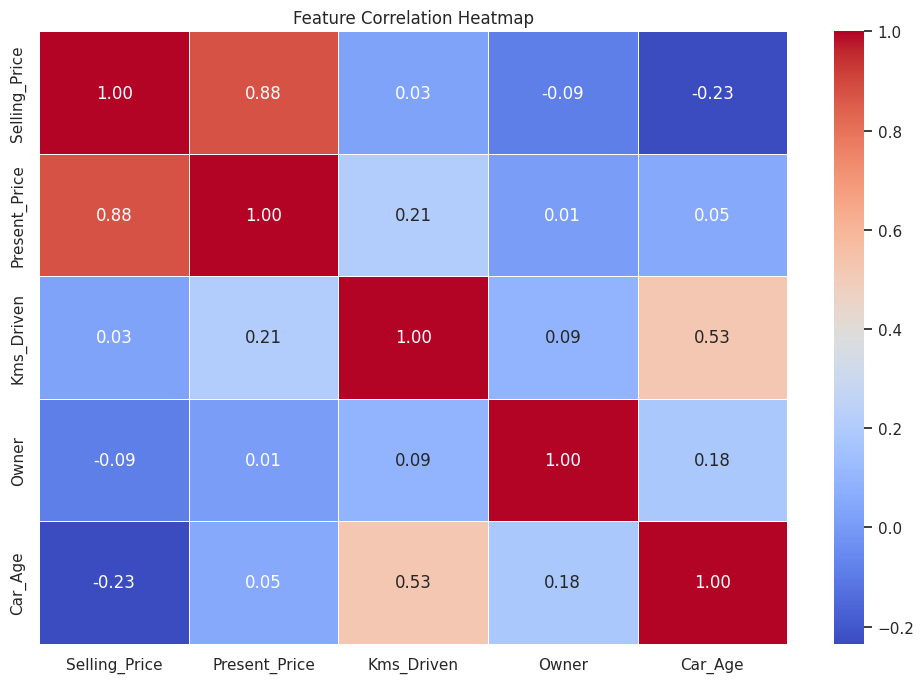


Correlation with Selling_Price:
Selling_Price    1.000000
Present_Price    0.876378
Kms_Driven       0.028566
Owner           -0.087880
Car_Age         -0.234369
Name: Selling_Price, dtype: float64


In [9]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print(f"\nCorrelation with Selling_Price:")
print(corr['Selling_Price'].sort_values(ascending=False))

### Key EDA Observations

1. **Present Price** has the strongest positive correlation with Selling Price
2. **Car Age** has a clear negative relationship — older cars sell for less
3. **Diesel cars** have higher average resale value (10.10 Lakhs) vs Petrol (3.26 Lakhs)
4. **Automatic transmission** cars have higher average price (9.07 Lakhs) vs Manual (3.92 Lakhs)
5. **Kilometers driven** has a moderate negative impact on price
6. **Maruti** is the most common brand in the dataset

---

# 4. Data Preprocessing

## 4.1 Encoding Categorical Variables
Converting text columns (Fuel_Type, Seller_Type, Transmission, Brand) into numbers using Label Encoding so our machine learning models can process them.

## 4.2 Train/Test Split
Splitting the data into 80% training and 20% testing sets to evaluate model performance on unseen data.

In [10]:
# Prepare data for modeling
df_model = df.copy()

# Encode categorical columns
label_encoders = {}
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()

print("Encoding:")
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le
    print(f"  ✅ {col}")

# Split features and target
X = df_model.drop('Selling_Price', axis=1)
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Split done!")
print(f"Training: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")
print(f"Features: {X.columns.tolist()}")

Encoding:
  ✅ Fuel_Type
  ✅ Seller_Type
  ✅ Transmission
  ✅ Brand

✅ Split done!
Training: 239 samples
Testing:  60 samples
Features: ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Brand']


# 5. Model Training & Evaluation

Training three different regression models and comparing their performance:

| Model | Description |
|-------|-------------|
| **Linear Regression** | Simple baseline — assumes linear relationships |
| **Random Forest** | Ensemble of decision trees — handles non-linearity |
| **Gradient Boosting** | Sequential boosting — builds trees to correct errors |

**Evaluation Metrics:**
- **MAE** — Average prediction error in Lakhs
- **RMSE** — Penalizes larger errors more heavily
- **R² Score** — How well the model explains variance (1.0 = perfect)

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2 Score': round(r2, 4)
    })
    fitted_models[name] = (model, y_pred)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
print(f"\n\n{'='*55}")
print("  MODEL COMPARISON")
print(f"{'='*55}")
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_name}")


  Linear Regression
  MAE:  1.5405
  RMSE: 2.5830
  R²:   0.7411

  Random Forest
  MAE:  1.3660
  RMSE: 3.3261
  R²:   0.5708

  Gradient Boosting
  MAE:  1.2015
  RMSE: 2.6643
  R²:   0.7246


  MODEL COMPARISON
            Model    MAE   RMSE  R2 Score
Linear Regression 1.5405 2.5830    0.7411
Gradient Boosting 1.2015 2.6643    0.7246
    Random Forest 1.3660 3.3261    0.5708

🏆 Best Model: Linear Regression


## 5.1 Actual vs Predicted — Best Model
Points closer to the red diagonal line indicate more accurate predictions. Ideally, all points would fall exactly on the line.

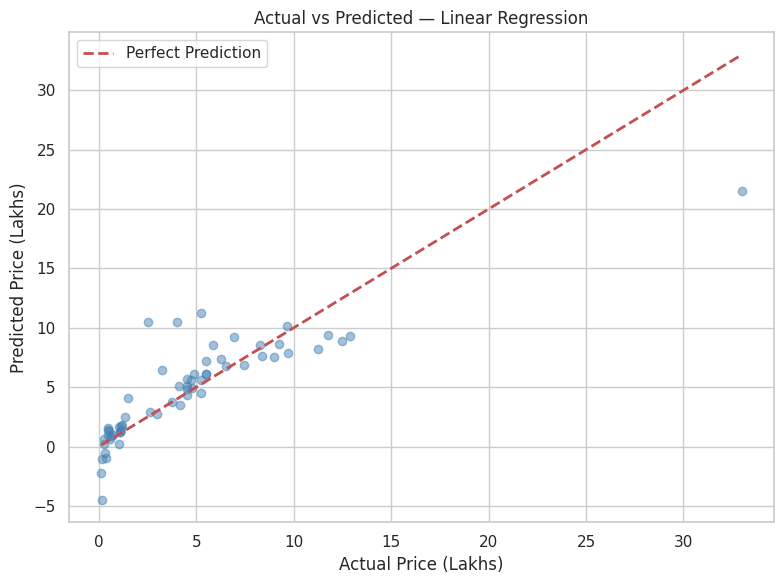

In [12]:
best_model, best_pred = fitted_models[best_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

## 5.2 Residual Plot — Best Model
Residuals (Actual - Predicted) should be randomly scattered around zero. A pattern would indicate the model is systematically missing something.

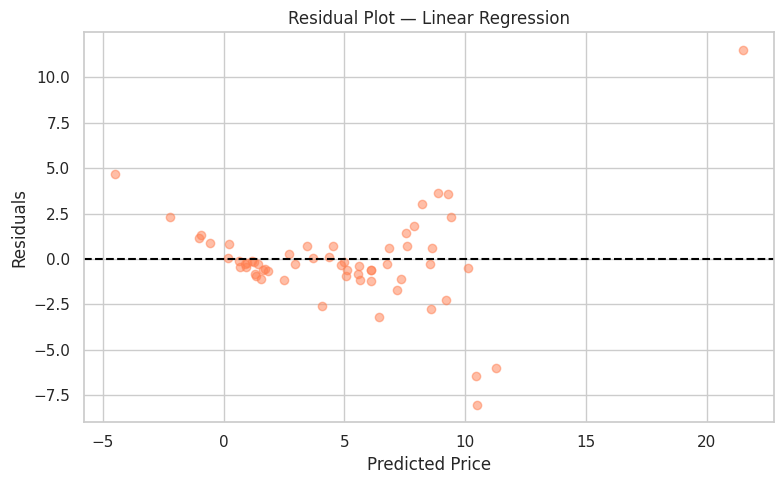

In [13]:
residuals = y_test.values - best_pred

plt.figure(figsize=(8, 5))
plt.scatter(best_pred, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title(f'Residual Plot — {best_name}')
plt.tight_layout()
plt.show()

# 6. Feature Importance Analysis
Using Random Forest to identify which features have the most impact on predicting car selling prices. Present_Price dominates as the strongest predictor.

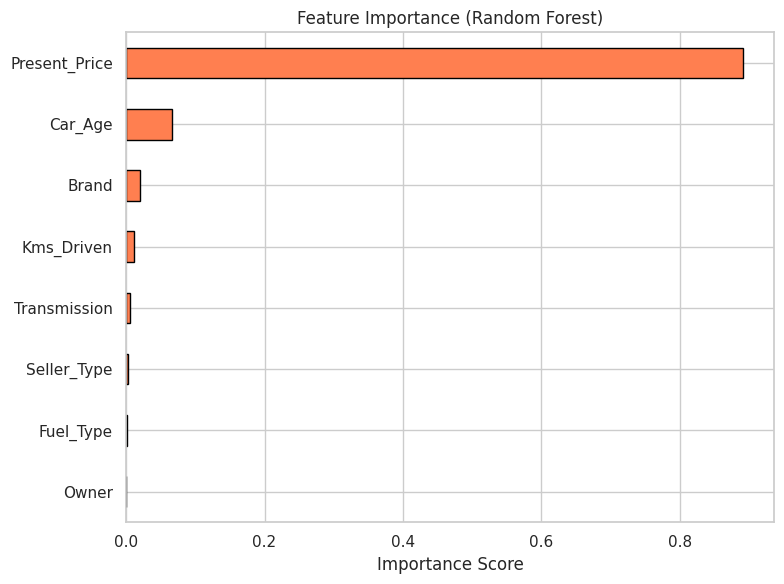


Ranking:
  Present_Price        → 0.8914
  Car_Age              → 0.0670
  Brand                → 0.0206
  Kms_Driven           → 0.0121
  Transmission         → 0.0052
  Seller_Type          → 0.0024
  Fuel_Type            → 0.0013
  Owner                → 0.0000


In [14]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nRanking:")
for feat, imp in importance.sort_values(ascending=False).items():
    print(f"  {feat:20s} → {imp:.4f}")

# 7. Conclusion

## Key Findings

1. **Present Price** (showroom price) is the strongest predictor of selling price
2. **Car Age** negatively impacts price — older cars sell for significantly less
3. **Diesel cars** have higher resale value compared to petrol cars
4. **Automatic transmission** cars hold their value better than manual
5. **Kms driven** has a moderate negative impact on selling price

## Skills Demonstrated
- Data Cleaning & Feature Engineering
- Exploratory Data Analysis (EDA) with multiple visualization types
- Regression Modeling (Linear Regression, Random Forest, Gradient Boosting)
- Model Evaluation using MAE, RMSE, and R²
- Feature Importance Analysis

In [15]:
print("""
╔═══════════════════════════════════════════════════════════╗
║          TASK 3: CAR PRICE PREDICTION                     ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  KEY FINDINGS:                                            ║
║  1. Present Price is the strongest predictor               ║
║  2. Car Age negatively impacts price                      ║
║  3. Diesel cars have higher resale value                  ║
║  4. Automatic cars hold value better                      ║
║  5. Kms driven has moderate negative impact               ║
║                                                           ║
║  SKILLS: Data Cleaning, Feature Engineering, EDA,         ║
║  Regression Modeling, Model Evaluation                    ║
╚═══════════════════════════════════════════════════════════╝
""")

best_row = results_df.iloc[0]
print(f"🏆 Best Model: {best_row['Model']}")
print(f"📊 MAE:  {best_row['MAE']}")
print(f"📊 RMSE: {best_row['RMSE']}")
print(f"📊 R²:   {best_row['R2 Score']}")
print("\n✅ Task 3 Complete!")


╔═══════════════════════════════════════════════════════════╗
║          TASK 3: CAR PRICE PREDICTION                     ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  KEY FINDINGS:                                            ║
║  1. Present Price is the strongest predictor               ║
║  2. Car Age negatively impacts price                      ║
║  3. Diesel cars have higher resale value                  ║
║  4. Automatic cars hold value better                      ║
║  5. Kms driven has moderate negative impact               ║
║                                                           ║
║  SKILLS: Data Cleaning, Feature Engineering, EDA,         ║
║  Regression Modeling, Model Evaluation                    ║
╚═══════════════════════════════════════════════════════════╝

🏆 Best Model: Linear Regression
📊 MAE:  1.5405
📊 RMSE: 2.583
📊 R²:   0.7411

✅ Task 3 Complete!
